In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import io
from helper import plot_to_tensorboard, count_parameters, MLPClassifier
import pandas as pd
import hashlib
from pathlib import Path
import mlflow
import mlflow.pytorch
from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils
from sklearn.model_selection import train_test_split

c:\ITBA\MINICONDA\envs\TrabajoPractico_1\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.7'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
mlflow.set_experiment("Clasificador_Imagenes_HP_Search")

<Experiment: artifact_location='file:///c:/ITBA/REDES%20NEURONALES/Tp1-Redes-Neuronales/mlruns/658278433750724451', creation_time=1779393889228, experiment_id='658278433750724451', last_update_time=1779393889228, lifecycle_stage='active', name='Clasificador_Imagenes_HP_Search', tags={}>

In [ ]:
def log_classification_report(model, loader, writer, device, classes, step, prefix="val"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    labels_presentes = sorted(list(set(list(all_labels) + list(all_preds))))
    classes_presentes = [classes[i] for i in labels_presentes]
    
    matriz_conf = confusion_matrix(all_labels, all_preds, labels=labels_presentes)
    fig_cm, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz_conf, display_labels=classes_presentes)
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    
    ax.set_title(f'{prefix.title()} - Confusion Matrix')

    fig_path = f"confusion_matrix_{prefix}_epoch_{step}.png"
    fig_cm.savefig(fig_path)
    mlflow.log_artifact(fig_path)
    os.remove(fig_path)

    plot_to_tensorboard(fig_cm, writer, f"{prefix}/confusion_matrix", step)
    plt.close(fig_cm)

    cls_report = classification_report(all_labels, all_preds, labels=labels_presentes, target_names=classes_presentes)
    writer.add_text(f"{prefix}/classification_report", f"<pre>{cls_report}</pre>", step)

    report_path = f"classification_report_{prefix}_epoch_{step}.txt"
    with open(report_path, "w") as f:
        f.write(cls_report)
    mlflow.log_artifact(report_path)
    os.remove(report_path)

In [ ]:
def evaluate(model, loader, writer, device, classes, criterion, epoch=None, prefix="val"):
    model.eval()  # Modo evaluación activo
    model.to(device) # Asegura el modelo en GPU/CPU
    
    log_classification_report(model, loader, writer, device, classes, step=epoch, prefix=prefix)

    correct, total, loss_sum = 0, 0, 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for i, (images, labels) in enumerate(loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            loss_sum += loss.item()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            if i == 0 and epoch is not None:
                img_grid = vutils.make_grid(images[:8].cpu(), normalize=True)
                writer.add_image(f"{prefix}/images", img_grid, global_step=epoch)

    acc = 100.0 * correct / total
    avg_loss = loss_sum / len(loader)

    if epoch is not None:
        writer.add_scalar(f"{prefix}/loss", avg_loss, epoch)
        writer.add_scalar(f"{prefix}/accuracy", acc, epoch)

    return avg_loss, acc

In [ ]:
class CustomImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

        # Extrae las clases según los nombres de las carpetas de las rutas filtradas
        self.classes = sorted(list(set([Path(p).parent.name for p in self.image_paths])))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        self.labels = [self.class_to_idx[Path(p).parent.name] for p in self.image_paths]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = np.array(Image.open(img_path).convert("RGB"))
        label = self.labels[idx]

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented["image"]

        return image, label  # <- Imagen en 3D (C, H, W). El modelo se encarga de aplanar

In [ ]:
# 1. JUNTAR TODO (Buscamos todas las imágenes en la raíz del split para unificarlas)
data_dir_total = Path("data/Split_smol")
all_paths = [p for p in data_dir_total.glob("**/*") if p.suffix.lower() in ['.jpg', '.jpeg', '.png']]

def get_class(x):
    return x.parent.name

# Cargamos todo en una lista limpia
all_files_data = []
for p in all_paths:
    try:
        with Image.open(p) as img:
            all_files_data.append((p, get_class(p)))
    except Exception:
        pass

df_total = pd.DataFrame(all_files_data, columns=["path", "class"]).sort_values(by="path").reset_index(drop=True)

# 2. SACAR REPES Y CONFLICTIVAS CON HASHES (Antes de separar)
foto_negra = "ISIC_0031430.jpg"
duplicado_interno = "ISIC_0031039.jpg"

hashes_vistos = set()
indices_a_mantener = []

for idx, row in df_total.iterrows():
    p = row["path"]
    # Filtro manual por nombre
    if p.name == foto_negra or p.name == duplicado_interno:
        continue
        
    # Filtro por hash (Elimina duplicados exactos en toda la base)
    with open(p, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
    
    if file_hash not in hashes_vistos:
        hashes_vistos.add(file_hash)
        indices_a_mantener.append(idx)

df_limpio = df_total.loc[indices_a_mantener].reset_index(drop=True)

# Convertimos a listas para el split matemático
all_image_paths = [str(p) for p in df_limpio["path"].tolist()]
all_labels = df_limpio["class"].tolist()

# 3. SPLIT METÓDICO 60 / 20 / 20 CON SEMILLA 42 
SEED = 42

# Primero separamos el 20% para el Test final
train_val_paths, test_image_paths, train_val_labels, _ = train_test_split(
    all_image_paths, all_labels, test_size=0.20, random_state=SEED, stratify=all_labels
)

# Del 80% restante, sacamos el 25% para Validación (que equivale al 20% del total general)
train_image_paths, val_image_paths, _, _ = train_test_split(
    train_val_paths, train_val_labels, test_size=0.25, random_state=SEED, stratify=train_val_labels
)

print(f"Misma metodología exacta (EDA e Instancia 1):")
print(f"Train: {len(train_image_paths)} | Val: {len(val_image_paths)} | Test: {len(test_image_paths)}")

C:\Users\Sofia\AppData\Local\Temp\ipykernel_956\3980641911.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test = df_val_completo.groupby('class', group_keys=False).apply(


Train: 695 | Val: 73 | Test: 75


In [7]:
# Crear directorio de logs de tensorboard
log_dir = "runs/experimento_skin_hp"
writer  = SummaryWriter(log_dir=log_dir)

In [8]:
# PASO 1 — Explorar HP base sin augmentations

hparams_space = {
    # --- FIJOS ---
    "input_size":   [64],
    "epochs":       20,
    "es_patience":  5,

    # --- A EXPLORAR ---
    "batch_size":   [32, 64],
    "lr":           [1e-3, 1e-4],
    "optimizer":    ["Adam", "RMSprop"],
    "weight_decay": [1e-3, 1e-4],
    "dropout":      [0.0, 0.25, 0.5],
    "hidden1":      [512, 768],
    "hidden2":      [128, 192],
}

c:\ITBA\MINICONDA\envs\TrabajoPractico_1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ITBA\MINICONDA\envs\TrabajoPractico_1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ITBA\MINICONDA\envs\TrabajoPractico_1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", resul

c:\ITBA\MINICONDA\envs\TrabajoPractico_1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ITBA\MINICONDA\envs\TrabajoPractico_1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ITBA\MINICONDA\envs\TrabajoPractico_1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026

ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of labels (9).

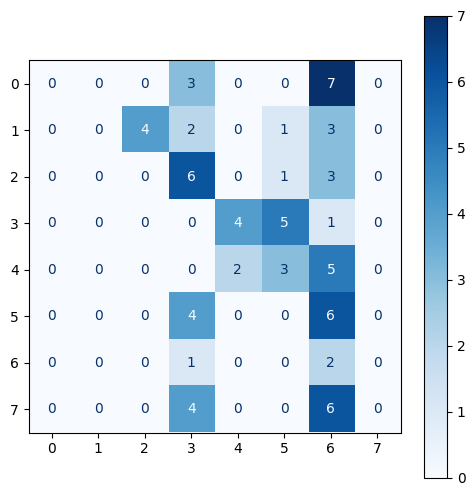

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

modelnbr = 0
for batch_size in hparams_space["batch_size"]:
    for lr in hparams_space["lr"]:
        for optimizer_name in hparams_space["optimizer"]:
            for weight_decay in hparams_space["weight_decay"]:
                for dropout in hparams_space["dropout"]:
                    for hidden1 in hparams_space["hidden1"]:
                        for hidden2 in hparams_space["hidden2"]:

                            modelnbr += 1

                            if modelnbr <= 27:
                                continue

                            print(f"Modelo número: {modelnbr}", end="\r")

                            input_size = hparams_space["input_size"][0]

                            hparams = {
                                "model":        "MLPClassifier",
                                "input_size":   input_size,
                                "batch_size":   batch_size,
                                "lr":           lr,
                                "epochs":       hparams_space["epochs"],
                                "optimizer":    optimizer_name,
                                "weight_decay": weight_decay,
                                "dropout":      dropout,
                                "es_patience":  hparams_space["es_patience"],
                                "hidden1":      hidden1,
                                "hidden2":      hidden2,
                                "loss_fn":      "CrossEntropyLoss",
                                "train_dir":    str(train_dir),
                                "val_dir":      str(val_dir),
                            }

                            train_transform = A.Compose([
                                A.Resize(input_size, input_size),
                                A.Normalize(),
                                ToTensorV2()
                            ])
                            val_transform = A.Compose([
                                A.Resize(input_size, input_size),
                                A.Normalize(),
                                ToTensorV2()
                            ])

                            train_dataset = CustomImageDataset(train_image_paths, transform=train_transform)
                            val_dataset   = CustomImageDataset(val_image_paths,   transform=val_transform)

                            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                            val_loader   = DataLoader(val_dataset,   batch_size=batch_size)

                            num_classes = len(train_dataset.classes)
                            model = MLPClassifier(
                                input_size=input_size ** 2 * 3,
                                hidden1=hidden1,
                                hidden2=hidden2,
                                dropout=dropout,
                                num_classes=num_classes
                            ).to(device)

                            criterion = nn.CrossEntropyLoss()
                            optimizer = (
                                optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
                                if optimizer_name == "Adam"
                                else torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
                            )

                            hparams["count_params"] = count_parameters(model)

                            with mlflow.start_run():
                                mlflow.log_params(hparams)

                                best_val_acc    = 0
                                best_val_loss   = 0
                                best_train_acc  = 0
                                best_train_loss = 0
                                best_epoch      = 0

                                for epoch in range(hparams["epochs"]):
                                    model.train()
                                    running_loss = 0.0
                                    correct, total = 0, 0

                                    for images, labels in train_loader:
                                        images, labels = images.to(device), labels.to(device)

                                        optimizer.zero_grad()
                                        outputs = model(images)
                                        loss = criterion(outputs, labels)
                                        loss.backward()
                                        optimizer.step()

                                        running_loss += loss.item()
                                        _, preds = torch.max(outputs, 1)
                                        correct += (preds == labels).sum().item()
                                        total   += labels.size(0)

                                    train_loss = running_loss / len(train_loader)
                                    train_acc  = 100.0 * correct / total

                                    val_loss, val_acc = evaluate(
                                        model, val_loader, writer, device,
                                        train_dataset.classes, criterion,
                                        epoch=epoch, prefix="val"
                                    )

                                    writer.add_scalar("train/loss",     train_loss, epoch)
                                    writer.add_scalar("train/accuracy", train_acc,  epoch)

                                    mlflow.log_metrics({
                                        "train_loss":     train_loss,
                                        "train_accuracy": train_acc,
                                        "val_loss":       val_loss,
                                        "val_accuracy":   val_acc
                                    }, step=epoch)

                                    if val_acc > best_val_acc:
                                        best_val_acc    = val_acc
                                        best_val_loss   = val_loss
                                        best_train_acc  = train_acc
                                        best_train_loss = train_loss
                                        best_epoch      = epoch
                                        torch.save(model.state_dict(), "mlp_model.pth")
                                        mlflow.log_artifact("mlp_model.pth")
                                        mlflow.pytorch.log_model(model, artifact_path="pytorch_model")

                                    elif epoch > best_epoch + hparams["es_patience"]:
                                        break

                                mlflow.log_metrics({
                                    "best_train_loss": best_train_loss,
                                    "best_train_acc":  best_train_acc,
                                    "best_val_loss":   best_val_loss,
                                    "best_val_acc":    best_val_acc,
                                    "best_epoch":      best_epoch
                                }, step=epoch + 1)

print(f"\nBúsqueda terminada. Se entrenaron {modelnbr} modelos.")